/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


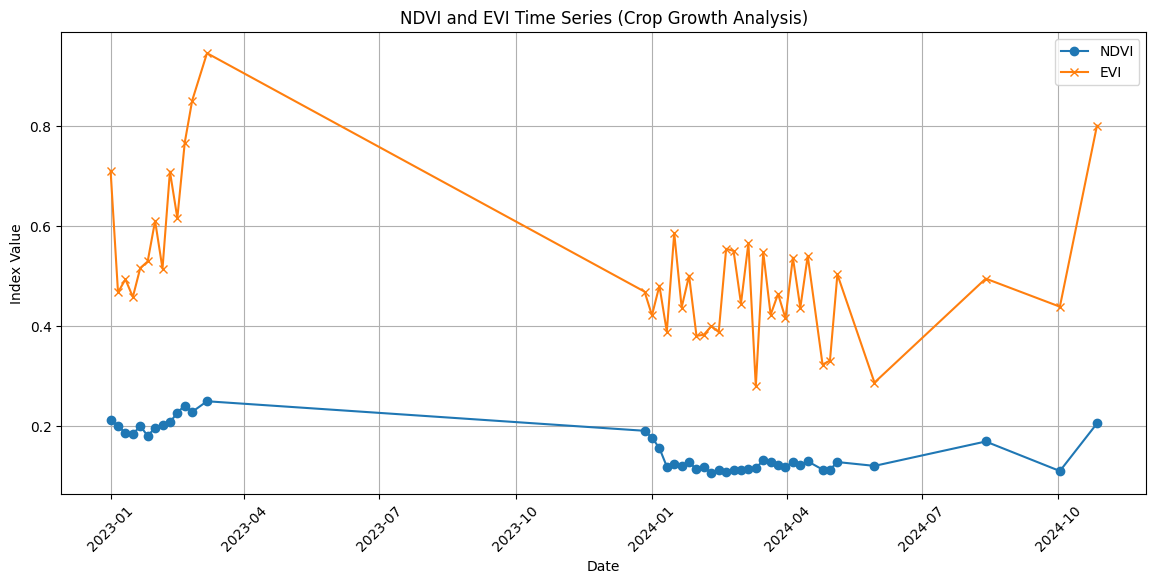

✅ Done! Combined NDVI + EVI data saved.


In [1]:
# =========================================
# INSTALL LIBRARIES
# =========================================
!pip install earthengine-api pandas matplotlib

# =========================================
# IMPORTS
# =========================================
import ee
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# AUTHENTICATION
# =========================================
ee.Authenticate()
ee.Initialize(project='handy-post-458213-t7')

# =========================================
# FARM BOUNDARY
# =========================================
roi = ee.Geometry.Polygon([
    [
        [75.619846, 16.287265],
        [75.61976, 16.287749],
        [75.623441, 16.287816],
        [75.623447, 16.287322],
        [75.619846, 16.287265]
    ]
])

# =========================================
# LOAD SENTINEL-2 DATA
# =========================================
dataset = (ee.ImageCollection('COPERNICUS/S2_SR')
           .filterBounds(roi)
           .filterDate('2023-01-01', '2024-12-31')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

# =========================================
# NDVI FUNCTION
# =========================================
def addNDVI(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

# =========================================
# EVI FUNCTION
# =========================================
def addEVI(image):
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
        {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }
    ).rename('EVI')
    return image.addBands(evi)

# Apply both
collection = dataset.map(addNDVI).map(addEVI)

# =========================================
# EXTRACT DATA
# =========================================
def extract_data(image):
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=10
    )

    return ee.Feature(None, {
        'date': image.date().format('YYYY-MM-dd'),
        'NDVI': stats.get('NDVI'),
        'EVI': stats.get('EVI')
    })

features = collection.map(extract_data)

# =========================================
# CONVERT TO DATAFRAME
# =========================================
data = features.getInfo()

dates = []
ndvi_vals = []
evi_vals = []

for f in data['features']:
    dates.append(f['properties']['date'])
    ndvi_vals.append(f['properties']['NDVI'])
    evi_vals.append(f['properties']['EVI'])

df = pd.DataFrame({
    'Date': pd.to_datetime(dates),
    'NDVI': ndvi_vals,
    'EVI': evi_vals
})

df = df.sort_values('Date')

# =========================================
# CLEAN EVI (REMOVE BAD VALUES)
# =========================================
df = df[(df['EVI'] > -0.2) & (df['EVI'] < 1)]

# =========================================
# PLOT COMBINED GRAPH
# =========================================
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['NDVI'], label='NDVI', marker='o')
plt.plot(df['Date'], df['EVI'], label='EVI', marker='x')

plt.xlabel('Date')
plt.ylabel('Index Value')
plt.title('NDVI and EVI Time Series (Crop Growth Analysis)')
plt.legend()
plt.grid()
plt.xticks(rotation=45)

plt.show()

# =========================================
# SAVE CSV
# =========================================
df.to_csv('NDVI_EVI_combined.csv', index=False)

print("✅ Done! Combined NDVI + EVI data saved.")